# **Taller 2: Interpolación.**
El presente taller tiene como objetivo aplicar **métodos de interpolación numérica** para el ajuste y análisis de un conjunto de datos experimentales. A través del desarrollo de funciones en Python, se busca comprender y poner en práctica diferentes técnicas de interpolación que permiten estimar valores intermedios entre puntos de datos conocidos. La interpolación es una herramienta fundamental en el análisis numérico, ya que facilita la creación de modelos matemáticos que describen fenómenos complejos a partir de datos discretos. En este taller, se trabajará con polinomios de interpolación y se implementarán algoritmos que permiten calcular estos polinomios de forma eficiente.

El taller se centrará en tres métodos principales de interpolación: el **polinomio de Newton**, el **polinomio de Lagrange** y la **interpolación mediante splines cúbicos**. Cada uno de estos métodos será desarrollado a partir de funciones en Python que operarán sobre un conjunto de datos experimentales proporcionado en el archivo `Datos Taller 2.txt`. Además del análisis numérico, se generarán gráficos que comparen visualmente los resultados de los polinomios de interpolación con los datos originales, permitiendo evaluar la precisión y el comportamiento de cada técnica en el rango de interés.

## **Introducción**

[**Ejercicio 1:**](#ejercicio-1) Cree una función en Python que, a partir de un conjunto de $n + 1$ datos, calcule el polinomio de interpolación de **Newton** de grado $n$. Grafique el polinomio de interpolación junto con los datos experimentales del archivo `Datos Taller 2.txt` en el rango $[0, 6]$.

[**Ejercicio 2:**](#ejercicio-2) Cree una función en Python que, a partir de un conjunto de $n + 1$ datos, calcule el polinomio de interpolación de **Lagrange** de grado $n$. Grafique el polinomio de interpolación junto con los datos experimentales del archivo `Datos Taller 2.txt` en el rango $[0, 6]$.

[**Ejercicio 3:**](#ejercicio-3) Cree una función en Python que, a partir de un conjunto de $n + 1$ datos, calcule el polinomio de interpolación mediante **splines cúbicos**. Grafique el polinomio de interpolación junto con los datos experimentales del archivo `Datos Taller 2.txt` en el rango $[0, 6]$.

## **Importaciones de librerias.**
En este apartado se procederá a la importación de las librerías necesarias para la ejecución del taller, las cuales han sido previamente definidas en el archivo **`requirements.txt`**. Estas librerías son fundamentales para garantizar la compatibilidad del entorno de trabajo y permiten implementar de manera eficiente los algoritmos de interpolación, así como realizar el procesamiento de datos experimentales y la visualización gráfica de los resultados. De este modo, se asegura una correcta ejecución de los ejercicios, facilitando tanto el análisis numérico como la interpretación visual del comportamiento de los polinomios generados.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sympy import symbols, expand
from scipy.interpolate import lagrange
colores = ["#2E8B57", "#FF5733"]

## **Ejercicio 1: Interpolación de Newton: Desarrollo e Implementación del Polinomio.**<a id="ejercicio-1"></a>
En este ejercicio, se requiere implementar una función en Python que permita calcular el **polinomio de interpolación de Newton** utilizando un conjunto de $n+1$ datos conocidos. La interpolación de Newton es una técnica basada en el uso de **diferencias divididas**, lo que facilita la construcción de un polinomio de grado $n$ que pasa exactamente por los puntos dados.

El método de **diferencias divididas** consiste en calcular una tabla en la que cada valor representa la diferencia entre valores sucesivos de la función dividida por la diferencia en los valores de la variable independiente. A partir de esta tabla, se obtienen los coeficientes del polinomio interpolador de Newton, el cual se expresa en forma de **producto acumulativo** con términos de la forma:

$$
P_n(x) = f(x_0) + (x - x_0)f[x_0, x_1] + (x - x_0)(x - x_1)f[x_0, x_1, x_2] + \dots + (x - x_0)(x - x_1) \dots (x - x_{n-1}) f[x_0, x_1, \dots, x_n]
$$

dónde $f[x_0, x_1, \dots, x_k]$ representa la diferencia dividida de orden $k$.

In [20]:
# Función para leer los datos desde un archivo txt.
def leer_datos(archivo):
    datos = np.loadtxt(archivo)
    x = datos[:, 0]
    y = datos[:, 1]
    return x, y

In [21]:
# Función para calcular las diferencias divididas de Newton. Coeficientes del Polinomio de Newton.
def diferencias_divididas(x, y):
    n = len(x)
    coeficientes = np.zeros((n, n)) # Matriz de ceros para almacenar los coeficientes.
    coeficientes[:, 0] = y # La primera columna es igual a los valores de y = f(x).

    for j in range(1, n):
        for i in range(n - j):
            coeficientes[i, j] = (coeficientes[i + 1, j - 1] - coeficientes[i, j - 1]) / (x[i + j] - x[i])

    return coeficientes[0, :]  # Retorna solo la primera fila con los coeficientes -> Diferencias divididas progresivas.

In [22]:
# Función para evaluar el polinomio de Newton en un conjunto de puntos.
def polinomio_newton(puntos, x_data, coeficientes):
    n = len(x_data)
    polinomio = np.zeros_like(puntos) # Vector de ceros para almacenar el polinomio.
    for i in range(n):
        term = coeficientes[i]
        for j in range(i):
            term *= (puntos - x_data[j]) # f(x_0) + f(x_0, x_1)(x - x_0) + f(x_0, x_1, x_2)(x - x_0)(x - x_1) + ...
        polinomio += term
    return polinomio

In [23]:
# Función construcción del polinomio de Newton de forma simbólica.
def polinomio_newton_simbolico(x_data, coeficientes_newton):
    x = symbols('x')
    n = len(x_data)
    polinomio_simbolico = coeficientes_newton[0]

    # (x - x_0)(x - x_1)...
    producto = 1
    for i in range(1, n):
        producto *= (x - x_data[i-1])
        polinomio_simbolico += coeficientes_newton[i] * producto

    polinomio_expandido = expand(polinomio_simbolico)
    return polinomio_expandido

### Resolución `Datos Taller 2`.
En este apartado, se aplica la interpolación de Newton utilizando los datos proporcionados en el archivo **`Datos Taller 2.txt`**. Se presentan los cálculos necesarios para obtener el polinomio interpolador y su posterior evaluación en un conjunto de puntos dentro del rango definido por los datos. Además, se incluye una representación gráfica que permite visualizar el ajuste del polinomio a los valores originales.

In [24]:
path = "../data"
x_data, y_data = leer_datos(f"{path}/Datos_Taller_2.txt")

In [25]:
# Cálculo de los coeficientes del polinomio de Newton.
coeficientes_newton = diferencias_divididas(x_data, y_data)
coeficientes_newton

array([ 3.        ,  2.        , -0.5       , -0.16666667,  0.125     ,
       -0.03333333,  0.00555556])

In [26]:
polinomio_newton_simbolico(x_data, coeficientes_newton)

0.00555555555555556*x**6 - 0.116666666666667*x**5 + 0.930555555555556*x**4 - 3.33333333333333*x**3 + 4.56388888888889*x**2 - 0.0500000000000003*x + 3.0

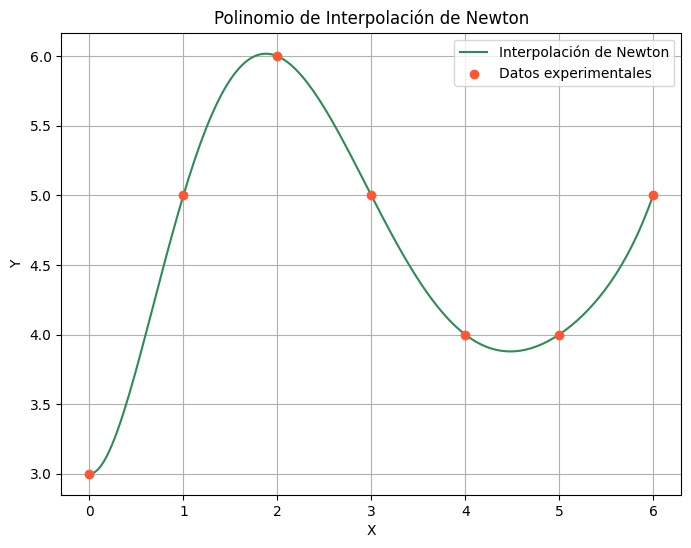

In [27]:
x_vals = np.linspace(0, 6, 200)
y_vals = polinomio_newton(x_vals, x_data, coeficientes_newton)

# Graficar los resultados
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label="Interpolación de Newton", color=colores[0])
plt.scatter(x_data, y_data, color=colores[1], label="Datos experimentales", zorder=3)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polinomio de Interpolación de Newton")
plt.legend()
plt.grid(True)
plt.show()

### Resolución `Datos Taller 2-B`.
En este apartado, se aplica la interpolación de Newton utilizando los datos proporcionados en el archivo **`Datos Taller 2-B.txt`**. Se presentan los cálculos necesarios para obtener el polinomio interpolador y su posterior evaluación en un conjunto de puntos dentro del rango definido por los datos. Además, se incluye una representación gráfica que permite visualizar el ajuste del polinomio a los valores originales.

In [28]:
x_data, y_data = leer_datos(f"{path}/Datos_Taller_2_B.txt")

In [29]:
# Cálculo de los coeficientes del polinomio de Newton.
coeficientes_newton = diferencias_divididas(x_data, y_data)

In [30]:
polinomio_newton_simbolico(x_data, coeficientes_newton)

-3.18773942560298e-30*x**99 + 1.57676250797593e-27*x**98 - 3.84665828979629e-25*x**97 + 6.1703836132819e-23*x**96 - 7.32051902328744e-21*x**95 + 6.85074129325486e-19*x**94 - 5.26699367329597e-17*x**93 + 3.42125489588723e-15*x**92 - 1.91642715996529e-13*x**91 + 9.40271818352753e-12*x**90 - 4.09065457298125e-10*x**89 + 1.59368603563356e-8*x**88 - 5.60548627289068e-7*x**87 + 1.79215285870039e-5*x**86 - 0.000523827079946259*x**85 + 0.0140667623974167*x**84 - 0.34853550977296*x**83 + 7.99766720312328*x**82 - 170.515309315199*x**81 + 3387.68169598541*x**80 - 62877.6783499883*x**79 + 1092800.22599443*x**78 - 17820819.0720991*x**77 + 273186555.899833*x**76 - 3943292415.93081*x**75 + 53676005425.8677*x**74 - 689945209709.024*x**73 + 8384914080140.22*x**72 - 96453712906616.5*x**71 + 1.05127773828505e+15*x**70 - 1.08666406674073e+16*x**69 + 1.06614539920961e+17*x**68 - 9.93598106482369e+17*x**67 + 8.80190665150961e+18*x**66 - 7.41624179571375e+19*x**65 + 5.94667943698881e+20*x**64 - 4.54010451683

esto es por oscilacione sya que el grado del polinomio de Newton es muy alto, sale correcvtamente en splines cúbicos. en todo caso  apra que diera bien se deberia de ahcer newton por tramos

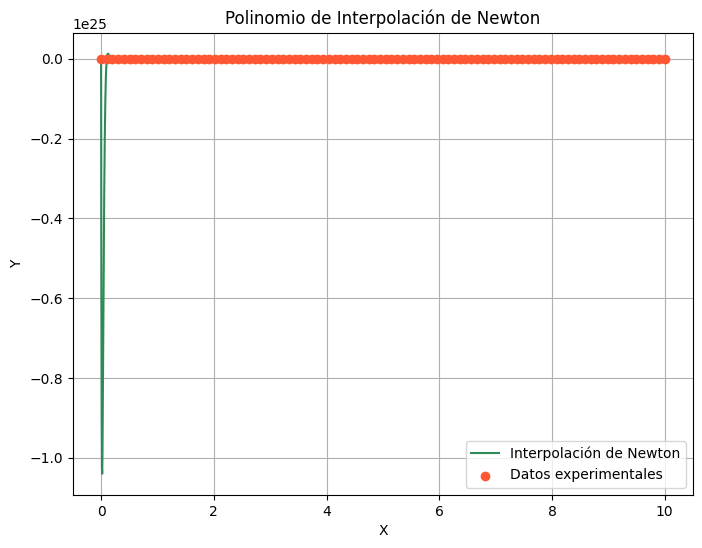

In [31]:
x_vals = np.linspace(0, 1, 200)
y_vals = polinomio_newton(x_vals, x_data, coeficientes_newton)

# Graficar los resultados
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label="Interpolación de Newton", color=colores[0])
plt.scatter(x_data, y_data, color=colores[1], label="Datos experimentales", zorder=3)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polinomio de Interpolación de Newton")
plt.legend()
plt.grid(True)
plt.show()

La gráfica resultante presenta un comportamiento altamente inestable, con valores extremadamente grandes y oscilaciones bruscas. Esto se debe a varios factores relacionados con la interpolación de Newton:

**1. Fenómeno de Runge.** El polinomio interpolador de Newton es un polinomio de grado **muy alto**. Cuando se utilizan polinomios de grado elevado para interpolar un conjunto de datos, pueden aparecer oscilaciones extremas en los extremos del intervalo, lo que se conoce como el **fenómeno de Runge**. Esto hace que la interpolación no se ajuste correctamente a los datos y genere valores descontrolados.

**2. Coeficientes de gran magnitud.** Los coeficientes del polinomio son extremadamente grandes en algunos términos (del orden de $10^{39}$), lo que indica que el modelo está sobreajustado a los datos. Esto es una consecuencia directa de utilizar una interpolación polinómica de alto grado, lo que puede provocar problemas numéricos graves debido a la inestabilidad en los cálculos.

**3. Problemas de estabilidad numérica.** Al calcular el polinomio de Newton con un alto número de puntos, los pequeños errores de redondeo en la representación numérica pueden amplificarse enormemente, lo que da lugar a valores extremos y comportamientos no deseados en la función interpolante.

Para evitar estos problemas, en lugar de utilizar interpolación polinómica de alto grado, es mejor emplear:
- **Interpolación con Splines Cúbicos**: Se utilizan polinomios de grado bajo en cada intervalo, lo que evita oscilaciones extremas.
- **Interpolación por partes**: En lugar de usar un único polinomio de alto grado, se pueden usar interpolaciones de menor grado en pequeños subconjuntos de los datos.
- **Métodos de regresión**: Si los datos tienen ruido, en lugar de interpolación exacta, puede ser más útil un ajuste por mínimos cuadrados.

## **Ejercicio 2: Interpolación de Lagrange: Cálculo y Representación Gráfica.**<a id="ejercicio-2"></a>
En este ejercicio, se implementa el **polinomio de interpolación de Lagrange**, un método utilizado para encontrar un polinomio que pase exactamente por un conjunto de puntos dados. La **interpolación de Lagrange** evita el cálculo de diferencias divididas y se basa en la construcción de funciones base $L_i(x)$, las cuales se combinan para formar el polinomio interpolador:

$$
f_n(x) = \sum_{i=0}^{n} L_i(x) f(x_i)
$$

dónde cada función base $L_i(x)$ se define como:

$$
L_i(x) = \prod_{\substack{j=0 \\ j\neq i}}^{n} \frac{x - x_j}{x_i - x_j}
$$

In [35]:
# Función para calcular los coeficientes de Lagrange L_i(x)
def lagrange_basis(x, x_data, i):
    n = len(x_data)
    L_i = 1
    for j in range(n):
        if j != i:
            L_i *= (x - x_data[j]) / (x_data[i] - x_data[j])
    return L_i

In [36]:
# Función para calcular el polinomio de interpolación de Lagrange
def polinomio_lagrange(x, x_data, y_data):
    n = len(x_data)
    resultado = 0
    for i in range(n):
        resultado += y_data[i] * lagrange_basis(x, x_data, i)
    return resultado

### Resolución `Datos Taller 2`.
En este apartado, se aplica la **interpolación de Lagrange** utilizando los datos proporcionados en el archivo **`Datos Taller 2.txt`**. Se desarrollan los cálculos necesarios para obtener el **polinomio interpolador de Lagrange**, construyendo las funciones base $L_i(x)$ y combinándolas para formar el polinomio final.

In [37]:
path = "../data"
x_data, y_data = leer_datos(f"{path}/Datos_Taller_2.txt")

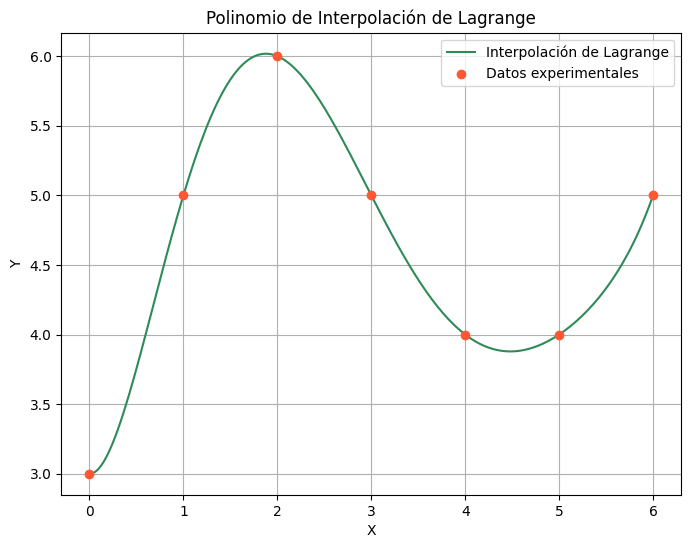

In [38]:
x_vals = np.linspace(0, 6, 200)
y_vals = np.array([polinomio_lagrange(x, x_data, y_data) for x in x_vals])

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label="Interpolación de Lagrange", color=colores[0])
plt.scatter(x_data, y_data, color=colores[1], label="Datos experimentales", zorder=3)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polinomio de Interpolación de Lagrange")
plt.legend()
plt.grid(True)
plt.show()

**Comprobación a través de Scipy.** Para validar la implementación del polinomio de interpolación de Lagrange, realizaremos una comprobación utilizando la biblioteca **Scipy**, que proporciona funciones optimizadas para la interpolación numérica.

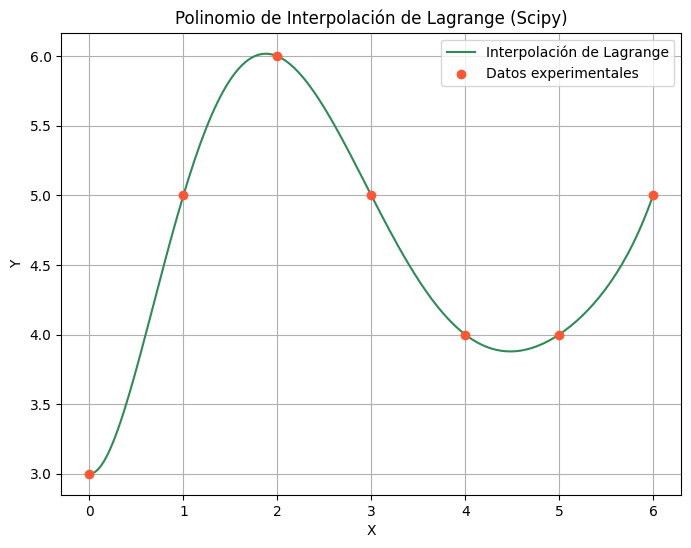

In [39]:
pol_lag = lagrange(x_data, y_data)

fig = plt.figure(figsize = (8, 6))
plt.plot(x_vals, pol_lag(x_vals), label="Interpolación de Lagrange", color=colores[0])
plt.scatter(x_data, y_data, color=colores[1], label="Datos experimentales", zorder=3)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polinomio de Interpolación de Lagrange (Scipy)")
plt.legend()
plt.grid(True)
plt.show()

### Resolución `Datos Taller 2-B`.
En este apartado, se aplica la **interpolación de Lagrange** utilizando los datos proporcionados en el archivo **`Datos Taller 2-B.txt`**. Se desarrollan los cálculos necesarios para obtener el **polinomio interpolador de Lagrange**, construyendo las funciones base $L_i(x)$ y combinándolas para formar el polinomio final.

In [40]:
path = "../data"
x_data, y_data = leer_datos(f"{path}/Datos_Taller_2_B.txt")

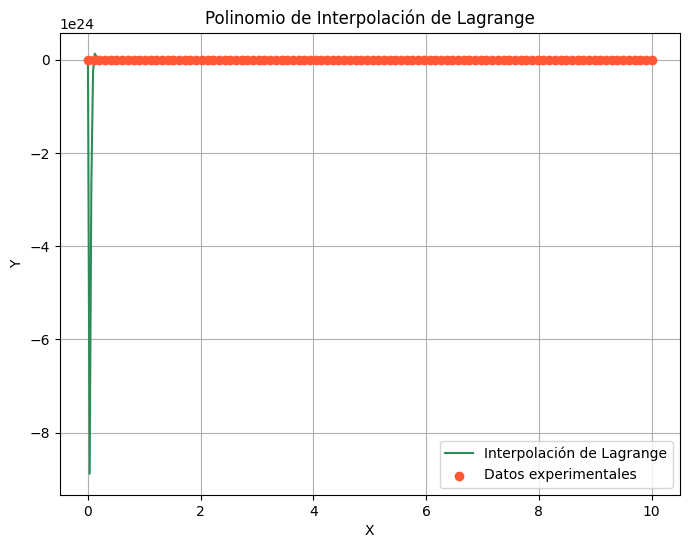

In [41]:
x_vals = np.linspace(0, 6, 200)
y_vals = np.array([polinomio_lagrange(x, x_data, y_data) for x in x_vals])

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label="Interpolación de Lagrange", color=colores[0])
plt.scatter(x_data, y_data, color=colores[1], label="Datos experimentales", zorder=3)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polinomio de Interpolación de Lagrange")
plt.legend()
plt.grid(True)
plt.show()

**Comprobación a través de Scipy.** Para validar la implementación del polinomio de interpolación de Lagrange, realizaremos una comprobación utilizando la biblioteca **Scipy**, que proporciona funciones optimizadas para la interpolación numérica.

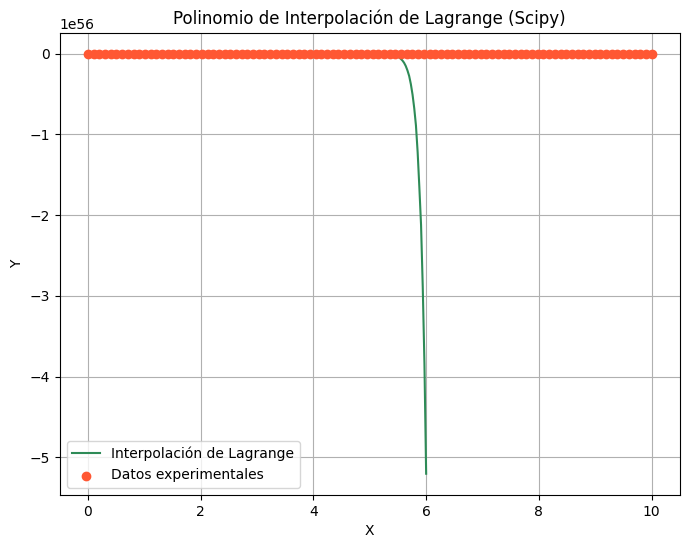

In [42]:
pol_lag = lagrange(x_data, y_data)

fig = plt.figure(figsize = (8, 6))
plt.plot(x_vals, pol_lag(x_vals), label="Interpolación de Lagrange", color=colores[0])
plt.scatter(x_data, y_data, color=colores[1], label="Datos experimentales", zorder=3)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polinomio de Interpolación de Lagrange (Scipy)")
plt.legend()
plt.grid(True)
plt.show()

Las gráficas de interpolación de Lagrange presentan un comportamiento errático y valores extremadamente grandes debido a los mismos problemas fundamentales que afectan la interpolación de Newton:

**1. Fenómeno de Runge.** El uso de polinomios de grado elevado en interpolación polinómica (como Lagrange y Newton) genera oscilaciones severas, especialmente en los extremos del intervalo. Esto ocurre porque los términos del polinomio de alto grado intentan ajustarse con precisión a todos los puntos dados, lo que provoca un comportamiento no deseado en regiones intermedias o externas.

**2. Crecimiento explosivo de los coeficientes.** En la interpolación de Lagrange, cada término del polinomio es una combinación de productos de la forma:

$$
L_i(x) = \prod_{\substack{j=0 \\ j\neq i}}^n \frac{x - x_j}{x_i - x_j}
$$

Cuando el número de puntos es grande, estos productos pueden generar coeficientes de gran magnitud, lo que da lugar a valores extremadamente altos o bajos en el polinomio resultante, afectando la estabilidad numérica.

**3. Problemas de estabilidad numérica.** Los errores numéricos se amplifican con polinomios de alto grado, lo que causa que el polinomio interpolador diverja en ciertos intervalos. Esto explica por qué la interpolación muestra valores descontrolados en algunos puntos de la gráfica.

Para evitar estos problemas, se recomienda utilizar:
- **Splines cúbicos:** Se ajustan múltiples polinomios de bajo grado en cada intervalo, evitando las oscilaciones extremas.
- **Interpolación por partes:** En lugar de un solo polinomio de alto grado, se pueden usar interpolaciones de menor grado en subconjuntos de los datos.
- **Regresión polinómica de grado moderado:** En lugar de interpolar exactamente todos los puntos, se puede buscar un ajuste óptimo por mínimos cuadrados.

## **Ejercicio 3: Interpolación con Splines Cúbicos: Modelado y Análisis de Datos.**<a id="ejercicio-3"></a>
En este ejercicio se aplica la interpolación con Splines Cúbicos para modelar un conjunto de datos, proporcionando una aproximación suave y precisa. A diferencia de otros métodos de interpolación polinómica, los Splines Cúbicos dividen el dominio en múltiples subintervalos y ajustan polinomios de tercer grado en cada uno, garantizando continuidad en la función y sus derivadas.

In [ ]:
# Construcción del spline cúbico natural. Devuelve los coeficientes de los polinomios por tramos.
def spline_cubico(x_data, y_data):
    n = len(x_data) - 1  # Número de intervalos.
    h = np.diff(x_data)  # Tamaño de cada subintervalo.
    b = np.diff(y_data) / h  # Diferencias divididas.

    # Matriz tridiagonal y vector de términos independientes.
    A = np.zeros((n + 1, n + 1))
    b_vec = np.zeros(n + 1)

    # Condiciones de frontera naturales.
    A[0, 0] = 1
    A[n, n] = 1

    for i in range(1, n):
        A[i, i - 1] = h[i - 1]
        A[i, i] = 2 * (h[i - 1] + h[i])
        A[i, i + 1] = h[i]
        b_vec[i] = 3 * (b[i] - b[i - 1])

    # Resolución del sistema tridiagonal para obtener segunda derivada (c coeficientes)
    c = np.linalg.solve(A, b_vec)

    # Calcular coeficientes a, b, c, d para cada subintervalo
    a = y_data[:-1]
    d = np.diff(c) / (3 * h)
    b = b - h * (2 * c[:-1] + c[1:]) / 3

    return a, b, c[:-1], d, x_data

In [89]:
# Evaluación del spline cúbico en un conjunto de puntos x.
def evaluar_spline(x, x_data, a, b, c, d):
    n = len(x_data) - 1
    y_vals = np.zeros_like(x)
    
    for i in range(n):
        indices = (x >= x_data[i]) & (x <= x_data[i + 1])
        dx = x[indices] - x_data[i]
        y_vals[indices] = a[i] + b[i] * dx + c[i] * dx**2 + d[i] * dx**3

    return y_vals

### Resolución `Datos Taller 2`.
En este apartado, se aplica la **interpolación con Splines Cúbicos** utilizando los datos proporcionados en el archivo **`Datos Taller 2.txt`**. Se desarrollan los cálculos necesarios para obtener el **modelo de interpolación por tramos**, dividiendo el dominio en varios subintervalos y ajustando polinomios de tercer grado en cada uno de ellos.

Para ello, se construyen los **sistemas de ecuaciones tridiagonales** necesarios para calcular los coeficientes del spline cúbico, garantizando la continuidad de la función y sus derivadas hasta el segundo orden. Posteriormente, la función interpoladora se evalúa en un conjunto de puntos dentro del rango de los datos originales, permitiendo obtener una representación continua y suavizada del modelo.

In [90]:
path = "../data"
x_data, y_data = leer_datos(f"{path}/Datos_Taller_2.txt")

In [91]:
# Construcción del spline cúbico.
a, b, c, d, x_knots = spline_cubico(x_data, y_data)

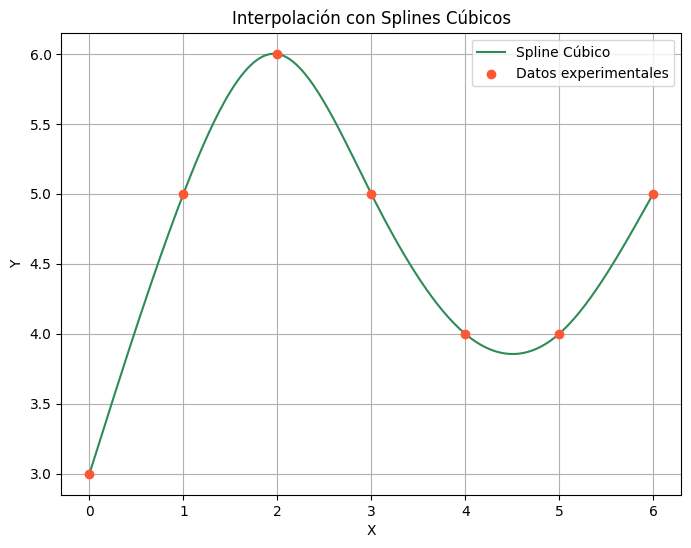

In [92]:
x_vals = np.linspace(np.min(x_data), np.max(x_data), 200)
y_vals = evaluar_spline(x_vals, x_knots, a, b, c, d)

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label="Spline Cúbico", color=colores[0])
plt.scatter(x_data, y_data, color=colores[1], label="Datos experimentales", zorder=3)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Interpolación con Splines Cúbicos")
plt.legend()
plt.grid(True)
plt.show()

### Resolución `Datos Taller 2-B`.
En este apartado, se aplica la **interpolación con Splines Cúbicos** utilizando los datos proporcionados en el archivo **`Datos Taller 2-B.txt`**. Se desarrollan los cálculos necesarios para obtener el **modelo de interpolación por tramos**, dividiendo el dominio en varios subintervalos y ajustando polinomios de tercer grado en cada uno de ellos.

Para ello, se construyen los **sistemas de ecuaciones tridiagonales** necesarios para calcular los coeficientes del spline cúbico, garantizando la continuidad de la función y sus derivadas hasta el segundo orden. Posteriormente, la función interpoladora se evalúa en un conjunto de puntos dentro del rango de los datos originales, permitiendo obtener una representación continua y suavizada del modelo.

In [93]:
x_data, y_data = leer_datos(f"{path}/Datos_Taller_2_B.txt")

In [94]:
# Construcción del spline cúbico.
a, b, c, d, x_knots = spline_cubico(x_data, y_data)

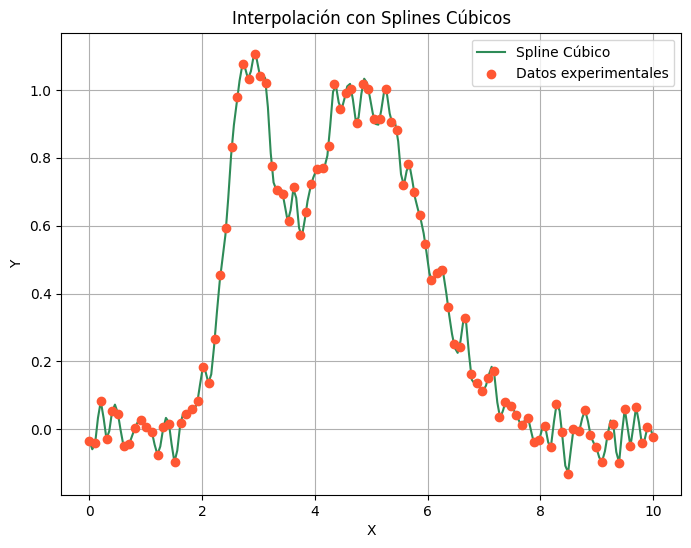

In [95]:
x_vals = np.linspace(np.min(x_data), np.max(x_data), 200)
y_vals = evaluar_spline(x_vals, x_knots, a, b, c, d)

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label="Spline Cúbico", color=colores[0])
plt.scatter(x_data, y_data, color=colores[1], label="Datos experimentales", zorder=3)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Interpolación con Splines Cúbicos")
plt.legend()
plt.grid(True)
plt.show()

La interpolación con splines cúbicos en esta gráfica muestra un ajuste mucho más estable y preciso en comparación con los polinomios de Newton y Lagrange.

La interpolación con splines cúbicos es una de las mejores opciones cuando se necesita interpolar datos sin introducir grandes errores ni oscilaciones artificiales. La gráfica se ve suave, estable y bien ajustada a los datos experimentales, lo que confirma que este método es mucho más eficaz que la interpolación polinómica global.